# Praktikum Week 03 — Filter Methods dan Wrapper Methods

Notebook ini membahas **feature selection for classification** pada dataset tabular campuran (numerik + kategorikal). Fokus utama praktikum adalah **filter methods** dan **wrapper methods**.


## Tujuan Praktikum

Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu:

- menyiapkan dataset tabular campuran untuk klasifikasi
- menjelaskan kenapa feature selection penting setelah encoding
- menerapkan beberapa **filter methods**
- menerapkan beberapa **wrapper methods**
- membandingkan hasil seleksi fitur dari berbagai metode
- mengevaluasi trade-off antara jumlah fitur, performa model, dan biaya komputasi


## Struktur Praktikum

1. Load dataset dan pahami struktur kolom
2. Preprocessing dan encoding
3. Baseline model
4. Filter methods
5. Wrapper methods
6. Perbandingan hasil
7. Latihan mandiri


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    SelectPercentile,
    GenericUnivariateSelect,
    f_classif,
    mutual_info_classif,
    chi2,
    SequentialFeatureSelector,
    RFE
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
plt.style.use('default')


## 1. Load Dataset

Dataset utama minggu ini adalah `training_dataset.csv`. Target klasifikasi yang ingin diprediksi adalah `berlangganan_deposito`.


In [2]:
from pathlib import Path

base_candidates = [
    Path('.'),
    Path('/kaggle/working'),
]

def resolve_dataset(filename):
    for base in base_candidates:
        candidate = base / filename
        if candidate.exists():
            return candidate

    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        matches = list(kaggle_input.rglob(filename))
        if matches:
            return matches[0]

    raise FileNotFoundError(f'Tidak menemukan {filename} di path lokal maupun Kaggle.')

train_path = resolve_dataset('training_dataset.csv')
valid_path = resolve_dataset('validation_set.csv')

df = pd.read_csv(train_path)
df_valid = pd.read_csv(valid_path)

print('Training path  :', train_path)
print('Validation path:', valid_path)
print('Shape training set :', df.shape)
print('Shape validation set:', df_valid.shape)

df.head()


Training path  : /kaggle/input/datasets/danzarchive/data-dsi/training_dataset.csv
Validation path: /kaggle/input/datasets/danzarchive/data-dsi/validation_set.csv
Shape training set : (22916, 22)
Shape validation set: (5729, 21)


,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,hari_kontak_terakhir,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,fri,2,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,thu,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,wed,2,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,wed,3,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0


### Observasi awal

- training set memiliki target `berlangganan_deposito`
- validation set tidak memiliki target
- dataset berisi kombinasi fitur numerik dan kategorikal
- beberapa kolom memiliki nilai `unknown`


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               22916 non-null  int64  
 1   usia                          22916 non-null  int64  
 2   pekerjaan                     22916 non-null  object 
 3   status_perkawinan             22916 non-null  object 
 4   pendidikan                    22916 non-null  object 
 5   gagal_bayar_sebelumnya        22916 non-null  object 
 6   pinjaman_rumah                22916 non-null  object 
 7   pinjaman_pribadi              22916 non-null  object 
 8   jenis_kontak                  22916 non-null  object 
 9   bulan_kontak_terakhir         22916 non-null  object 
 10  hari_kontak_terakhir          22916 non-null  object 
 11  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 12  hari_sejak_kontak_sebelumnya  22916 non-null  int64  
 13  j

In [4]:
target_distribution = df['berlangganan_deposito'].value_counts().sort_index()
target_ratio = df['berlangganan_deposito'].value_counts(normalize=True).sort_index()

summary_target = pd.DataFrame({
    'count': target_distribution,
    'proportion': target_ratio.round(4)
})
summary_target


,count,proportion
berlangganan_deposito,,
0,20302,0.8859
1,2614,0.1141


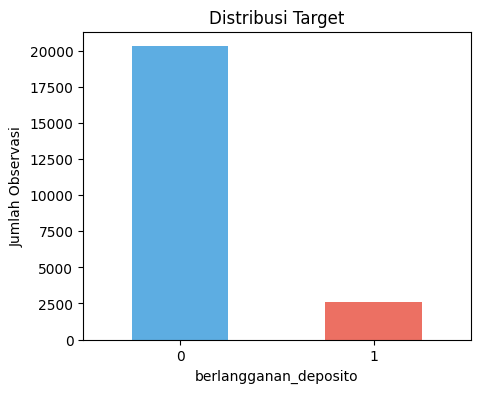

In [5]:
ax = target_distribution.plot(kind='bar', color=['#5dade2', '#ec7063'], figsize=(5, 4))
ax.set_title('Distribusi Target')
ax.set_xlabel('berlangganan_deposito')
ax.set_ylabel('Jumlah Observasi')
plt.xticks(rotation=0)
plt.show()


Dataset ini **tidak seimbang**. Kelas `0` jauh lebih banyak daripada kelas `1`. Ini perlu diingat saat mengevaluasi model — accuracy saja tidak selalu cukup.


## 2. Inspeksi Tipe Fitur

Sebelum melakukan feature selection, kita perlu tahu fitur mana yang numerik, mana yang kategorikal, dan mana yang sebaiknya tidak dipakai langsung sebagai prediktor.


In [6]:
df.dtypes


customer_number                   int64
usia                              int64
pekerjaan                        object
status_perkawinan                object
pendidikan                       object
gagal_bayar_sebelumnya           object
pinjaman_rumah                   object
pinjaman_pribadi                 object
jenis_kontak                     object
bulan_kontak_terakhir            object
hari_kontak_terakhir             object
jumlah_kontak_kampanye_ini        int64
hari_sejak_kontak_sebelumnya      int64
jumlah_kontak_sebelumnya          int64
hasil_kampanye_sebelumnya        object
tingkat_variasi_pekerjaan       float64
indeks_harga_konsumen           float64
indeks_kepercayaan_konsumen     float64
suku_bunga_euribor_3bln         float64
jumlah_pekerja                  float64
pulau                            object
berlangganan_deposito             int64
dtype: object

In [7]:
numeric_columns = [
    'usia',
    'jumlah_kontak_kampanye_ini',
    'hari_sejak_kontak_sebelumnya',
    'jumlah_kontak_sebelumnya',
    'tingkat_variasi_pekerjaan',
    'indeks_harga_konsumen',
    'indeks_kepercayaan_konsumen',
    'suku_bunga_euribor_3bln',
    'jumlah_pekerja'
]

identifier_columns = ['customer_number']
target_column = 'berlangganan_deposito'

categorical_columns = [
    col for col in df.columns
    if col not in numeric_columns + identifier_columns + [target_column]
]

print('Jumlah fitur numerik    :', len(numeric_columns))
print('Jumlah fitur kategorikal:', len(categorical_columns))
print('Kolom ID-like           :', identifier_columns)

print('\nFitur kategorikal:')
for col in categorical_columns:
    print('-', col)


Jumlah fitur numerik    : 9
Jumlah fitur kategorikal: 11
Kolom ID-like           : ['customer_number']

Fitur kategorikal:
- pekerjaan
- status_perkawinan
- pendidikan
- gagal_bayar_sebelumnya
- pinjaman_rumah
- pinjaman_pribadi
- jenis_kontak
- bulan_kontak_terakhir
- hari_kontak_terakhir
- hasil_kampanye_sebelumnya
- pulau


### Catatan penting

Kolom `customer_number` terlihat seperti **identifier**, bukan fitur perilaku atau profil yang memang relevan untuk prediksi. Karena itu, kolom ini akan dibuang dari modeling.


In [8]:
unknown_summary = pd.DataFrame({
    'unknown_count': [(df[col] == 'unknown').sum() if df[col].dtype == 'object' else 0 for col in df.columns]
}, index=df.columns).sort_values('unknown_count', ascending=False)

unknown_summary.head(10)


,unknown_count
gagal_bayar_sebelumnya,4745
pendidikan,992
pinjaman_pribadi,579
pinjaman_rumah,579
pekerjaan,193
status_perkawinan,47
customer_number,0
usia,0
jenis_kontak,0
bulan_kontak_terakhir,0


Nilai `unknown` tidak otomatis dianggap missing value formal (`NaN`), tetapi tetap perlu diperhatikan karena dapat memengaruhi encoding dan interpretasi fitur. Pada praktikum ini, kita **biarkan sebagai kategori valid** agar mahasiswa bisa melihat konsekuensinya setelah one-hot encoding.


## 3. Preprocessing dan Encoding

Pada problem klasifikasi tabular, fitur kategorikal perlu diubah menjadi numerik terlebih dahulu. Untuk transparansi pembelajaran, kita akan memakai `pd.get_dummies()`.


In [9]:
df_model = df.drop(columns=identifier_columns).copy()

X_raw = df_model.drop(columns=[target_column])
y = df_model[target_column].astype(int)

X_encoded = pd.get_dummies(X_raw, columns=categorical_columns, drop_first=False, dtype=int)

print('Shape sebelum encoding :', X_raw.shape)
print('Shape sesudah encoding :', X_encoded.shape)
X_encoded.head()


Shape sebelum encoding : (22916, 20)
Shape sesudah encoding : (22916, 70)


,usia,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pekerjaan_asisten rumah tangga,pekerjaan_entrepreneur,pekerjaan_mahasiswa,pekerjaan_manajer,pekerjaan_pekerja kasar,pekerjaan_pemilik bisnis,pekerjaan_pengangguran,pekerjaan_pensiunan,pekerjaan_penyedia jasa,pekerjaan_sosial media specialis,pekerjaan_teknisi,pekerjaan_unknown,status_perkawinan_cerai,status_perkawinan_lajang,status_perkawinan_menikah,status_perkawinan_unknown,pendidikan_Diploma,pendidikan_Pendidikan Tinggi,pendidikan_SD,pendidikan_SMA,pendidikan_SMP,pendidikan_TIDAK SEKOLAH,pendidikan_Tidak Tamat SD,pendidikan_unknown,gagal_bayar_sebelumnya_no,gagal_bayar_sebelumnya_unknown,gagal_bayar_sebelumnya_yes,pinjaman_rumah_no,pinjaman_rumah_unknown,pinjaman_rumah_yes,pinjaman_pribadi_no,pinjaman_pribadi_unknown,pinjaman_pribadi_yes,jenis_kontak_cellular,jenis_kontak_telephone,bulan_kontak_terakhir_apr,bulan_kontak_terakhir_aug,bulan_kontak_terakhir_dec,bulan_kontak_terakhir_jul,bulan_kontak_terakhir_jun,bulan_kontak_terakhir_mar,bulan_kontak_terakhir_may,bulan_kontak_terakhir_nov,bulan_kontak_terakhir_oct,bulan_kontak_terakhir_sep,hari_kontak_terakhir_fri,hari_kontak_terakhir_mon,hari_kontak_terakhir_thu,hari_kontak_terakhir_tue,hari_kontak_terakhir_wed,hasil_kampanye_sebelumnya_failure,hasil_kampanye_sebelumnya_nonexistent,hasil_kampanye_sebelumnya_success,pulau_Bali,pulau_Jawa,pulau_Kalimantan,pulau_NTB,pulau_NTT,pulau_Papua,pulau_Sulawesi,pulau_Sumatera
0,63,2,999,0,-1.7,94.215,-40.3,0.885,4991.6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,43,2,999,0,-0.1,93.200,-42.0,4.021,5195.8,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2,29,1,999,0,1.4,93.918,-42.7,4.958,5228.1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
3,40,2,999,0,1.1,93.994,-36.4,4.859,5191.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1
4,40,3,999,0,1.4,93.444,-36.1,4.964,5228.1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0


Setelah encoding, jumlah fitur naik cukup banyak. Inilah titik di mana feature selection menjadi penting.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Shape X_train:', X_train.shape)
print('Shape X_test :', X_test.shape)


Shape X_train: (18332, 70)
Shape X_test : (4584, 70)


## 4. Baseline Model

Kita mulai dari baseline **Logistic Regression** dengan semua fitur hasil encoding. Nanti semua metode feature selection dibandingkan terhadap baseline ini.


In [11]:
def evaluate_model(model, X_train, X_test, y_train, y_test, method_name, n_features, selected_feature_names):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'method': method_name,
        'n_features': int(n_features),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'selected_features': list(selected_feature_names)
    }

base_model = LogisticRegression(max_iter=2000, class_weight='balanced')

results = []
feature_sets = {}

baseline_result = evaluate_model(
    base_model,
    X_train,
    X_test,
    y_train,
    y_test,
    method_name='Baseline (all features)',
    n_features=X_train.shape[1],
    selected_feature_names=X_train.columns
)

results.append(baseline_result)
feature_sets['Baseline (all features)'] = list(X_train.columns)

pd.DataFrame(results).drop(columns=['selected_features'])


,method,n_features,accuracy,precision,recall,f1
0,Baseline (all features),70,0.811082,0.333333,0.655832,0.44201


In [12]:
print(classification_report(y_test, base_model.fit(X_train, y_train).predict(X_test), digits=4))


              precision    recall  f1-score   support

           0     0.9494    0.8311    0.8863      4061
           1     0.3333    0.6558    0.4420       523

    accuracy                         0.8111      4584
   macro avg     0.6414    0.7435    0.6642      4584
weighted avg     0.8791    0.8111    0.8356      4584



## 5. Filter Methods

Pada bagian ini, kita akan mencoba beberapa pendekatan filter. Intinya: fitur dinilai berdasarkan skor statistik atau properti tertentu, tanpa membungkus model utama secara iteratif.


### 5.1 Variance Threshold

Metode ini membuang fitur dengan variasi yang sangat rendah. Sangat relevan setelah one-hot encoding karena beberapa dummy variables bisa hampir selalu bernilai 0.

**Cocok untuk:**

- fitur numerik
- fitur kategorikal yang sudah di-encoding menjadi dummy / one-hot
- tidak dipakai langsung pada string kategorikal mentah


In [13]:
vt_selector = VarianceThreshold(threshold=0.001)
X_train_vt = vt_selector.fit_transform(X_train)
X_test_vt = vt_selector.transform(X_test)

vt_features = X_train.columns[vt_selector.get_support()]

print('Jumlah fitur sebelum VT :', X_train.shape[1])
print('Jumlah fitur sesudah VT :', X_train_vt.shape[1])
print('Contoh fitur yang bertahan:')
print(vt_features[:15].tolist())


Jumlah fitur sebelum VT : 70
Jumlah fitur sesudah VT : 68
Contoh fitur yang bertahan:
['usia', 'jumlah_kontak_kampanye_ini', 'hari_sejak_kontak_sebelumnya', 'jumlah_kontak_sebelumnya', 'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen', 'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln', 'jumlah_pekerja', 'pekerjaan_asisten rumah tangga', 'pekerjaan_entrepreneur', 'pekerjaan_mahasiswa', 'pekerjaan_manajer', 'pekerjaan_pekerja kasar', 'pekerjaan_pemilik bisnis']


In [14]:
vt_model = LogisticRegression(max_iter=2000, class_weight='balanced')
vt_result = evaluate_model(vt_model, X_train_vt, X_test_vt, y_train, y_test, 'VarianceThreshold', X_train_vt.shape[1], vt_features)
results.append(vt_result)
feature_sets['VarianceThreshold'] = list(vt_features)
vt_result


{'method': 'VarianceThreshold',
 'n_features': 68,
 'accuracy': 0.8095549738219895,
 'precision': 0.3310810810810811,
 'recall': 0.655831739961759,
 'f1': 0.4400256574727389,
 'selected_features': ['usia',
  'jumlah_kontak_kampanye_ini',
  'hari_sejak_kontak_sebelumnya',
  'jumlah_kontak_sebelumnya',
  'tingkat_variasi_pekerjaan',
  'indeks_harga_konsumen',
  'indeks_kepercayaan_konsumen',
  'suku_bunga_euribor_3bln',
  'jumlah_pekerja',
  'pekerjaan_asisten rumah tangga',
  'pekerjaan_entrepreneur',
  'pekerjaan_mahasiswa',
  'pekerjaan_manajer',
  'pekerjaan_pekerja kasar',
  'pekerjaan_pemilik bisnis',
  'pekerjaan_pengangguran',
  'pekerjaan_pensiunan',
  'pekerjaan_penyedia jasa',
  'pekerjaan_sosial media specialis',
  'pekerjaan_teknisi',
  'pekerjaan_unknown',
  'status_perkawinan_cerai',
  'status_perkawinan_lajang',
  'status_perkawinan_menikah',
  'status_perkawinan_unknown',
  'pendidikan_Diploma',
  'pendidikan_Pendidikan Tinggi',
  'pendidikan_SD',
  'pendidikan_SMA',
  '

### 5.2 SelectKBest dengan `f_classif`

Di sini kita pilih **20 fitur terbaik** berdasarkan ANOVA F-score.

**Cocok untuk:**

- fitur numerik
- fitur kategorikal yang sudah di-encoding
- kurang cocok dipakai langsung pada fitur kategorikal mentah


In [15]:
k_top = 20

f_selector = SelectKBest(score_func=f_classif, k=k_top)
X_train_f = f_selector.fit_transform(X_train, y_train)
X_test_f = f_selector.transform(X_test)
f_features = X_train.columns[f_selector.get_support()]

f_scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': f_selector.scores_
}).sort_values('score', ascending=False)

f_scores.head(15)


,feature,score
8,jumlah_pekerja,2635.627109
2,hari_sejak_kontak_sebelumnya,2165.757676
61,hasil_kampanye_sebelumnya_success,2032.147960
7,suku_bunga_euribor_3bln,1995.384365
4,tingkat_variasi_pekerjaan,1871.801225
3,jumlah_kontak_sebelumnya,972.792181
60,hasil_kampanye_sebelumnya_nonexistent,736.189933
43,jenis_kontak_telephone,425.807383
42,jenis_kontak_cellular,425.807383
5,indeks_harga_konsumen,424.740796


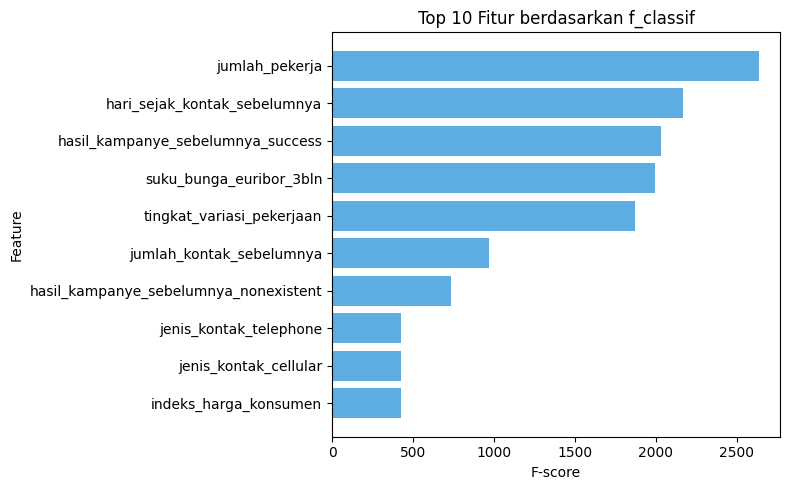

In [16]:
plt.figure(figsize=(8, 5))
plt.barh(f_scores.head(10)['feature'][::-1], f_scores.head(10)['score'][::-1], color='#5dade2')
plt.title('Top 10 Fitur berdasarkan f_classif')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [17]:
f_model = LogisticRegression(max_iter=2000, class_weight='balanced')
f_result = evaluate_model(f_model, X_train_f, X_test_f, y_train, y_test, 'SelectKBest + f_classif', X_train_f.shape[1], f_features)
results.append(f_result)
feature_sets['SelectKBest + f_classif'] = list(f_features)
f_result


{'method': 'SelectKBest + f_classif',
 'n_features': 20,
 'accuracy': 0.7770506108202443,
 'precision': 0.29015979814970566,
 'recall': 0.6596558317399618,
 'f1': 0.4030373831775701,
 'selected_features': ['hari_sejak_kontak_sebelumnya',
  'jumlah_kontak_sebelumnya',
  'tingkat_variasi_pekerjaan',
  'indeks_harga_konsumen',
  'suku_bunga_euribor_3bln',
  'jumlah_pekerja',
  'pekerjaan_mahasiswa',
  'pekerjaan_pekerja kasar',
  'pekerjaan_pensiunan',
  'gagal_bayar_sebelumnya_no',
  'gagal_bayar_sebelumnya_unknown',
  'jenis_kontak_cellular',
  'jenis_kontak_telephone',
  'bulan_kontak_terakhir_apr',
  'bulan_kontak_terakhir_mar',
  'bulan_kontak_terakhir_may',
  'bulan_kontak_terakhir_oct',
  'bulan_kontak_terakhir_sep',
  'hasil_kampanye_sebelumnya_nonexistent',
  'hasil_kampanye_sebelumnya_success']}

### 5.3 SelectKBest dengan `mutual_info_classif`

Mutual information dapat menangkap dependensi non-linear antara fitur dan target.

**Cocok untuk:**

- fitur numerik
- fitur kategorikal yang sudah di-encoding
- lebih fleksibel dibanding `f_classif` ketika relasi fitur-target tidak sederhana


In [18]:
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_top)
X_train_mi = mi_selector.fit_transform(X_train, y_train)
X_test_mi = mi_selector.transform(X_test)
mi_features = X_train.columns[mi_selector.get_support()]

mi_scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': mi_selector.scores_
}).sort_values('score', ascending=False)

mi_scores.head(15)


,feature,score
7,suku_bunga_euribor_3bln,0.071308
5,indeks_harga_konsumen,0.066074
6,indeks_kepercayaan_konsumen,0.064154
8,jumlah_pekerja,0.063652
4,tingkat_variasi_pekerjaan,0.055051
2,hari_sejak_kontak_sebelumnya,0.034198
61,hasil_kampanye_sebelumnya_success,0.028581
3,jumlah_kontak_sebelumnya,0.018234
60,hasil_kampanye_sebelumnya_nonexistent,0.016880
43,jenis_kontak_telephone,0.016506


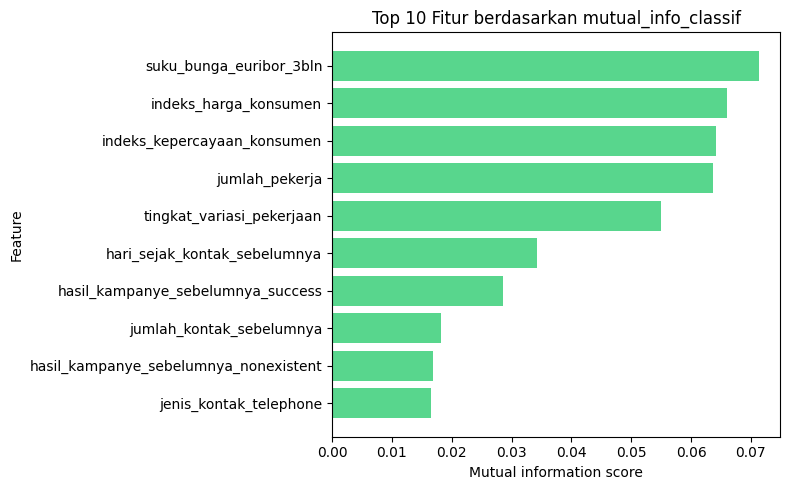

In [19]:
plt.figure(figsize=(8, 5))
plt.barh(mi_scores.head(10)['feature'][::-1], mi_scores.head(10)['score'][::-1], color='#58d68d')
plt.title('Top 10 Fitur berdasarkan mutual_info_classif')
plt.xlabel('Mutual information score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [20]:
mi_model = LogisticRegression(max_iter=2000, class_weight='balanced')
mi_result = evaluate_model(mi_model, X_train_mi, X_test_mi, y_train, y_test, 'SelectKBest + mutual_info', X_train_mi.shape[1], mi_features)
results.append(mi_result)
feature_sets['SelectKBest + mutual_info'] = list(mi_features)
mi_result


{'method': 'SelectKBest + mutual_info',
 'n_features': 20,
 'accuracy': 0.7942844677137871,
 'precision': 0.30943738656987296,
 'recall': 0.6520076481835564,
 'f1': 0.4196923076923077,
 'selected_features': ['usia',
  'hari_sejak_kontak_sebelumnya',
  'jumlah_kontak_sebelumnya',
  'tingkat_variasi_pekerjaan',
  'indeks_harga_konsumen',
  'indeks_kepercayaan_konsumen',
  'suku_bunga_euribor_3bln',
  'jumlah_pekerja',
  'pekerjaan_pensiunan',
  'status_perkawinan_menikah',
  'pendidikan_Pendidikan Tinggi',
  'gagal_bayar_sebelumnya_no',
  'jenis_kontak_cellular',
  'jenis_kontak_telephone',
  'bulan_kontak_terakhir_mar',
  'bulan_kontak_terakhir_may',
  'bulan_kontak_terakhir_oct',
  'hasil_kampanye_sebelumnya_nonexistent',
  'hasil_kampanye_sebelumnya_success',
  'pulau_Kalimantan']}

### 5.4 SelectKBest dengan `chi2`

`chi2` mengharuskan semua fitur bernilai **non-negative**. Karena itu kita perlu men-scale fitur numerik dengan `MinMaxScaler`, lalu menggabungkannya lagi dengan hasil one-hot encoding.

**Cocok untuk:**

- fitur kategorikal yang sudah di-one-hot encode
- data frekuensi dan text features non-negative
- fitur numerik yang sudah dibuat non-negative
- tidak dipakai langsung pada string kategorikal mentah


In [21]:
numeric_train = X_train[numeric_columns].copy()
numeric_test = X_test[numeric_columns].copy()

scaler = MinMaxScaler()
numeric_train_scaled = pd.DataFrame(
    scaler.fit_transform(numeric_train),
    columns=numeric_columns,
    index=X_train.index
)
numeric_test_scaled = pd.DataFrame(
    scaler.transform(numeric_test),
    columns=numeric_columns,
    index=X_test.index
)

non_numeric_columns = [col for col in X_train.columns if col not in numeric_columns]

X_train_nonneg = pd.concat([numeric_train_scaled, X_train[non_numeric_columns]], axis=1)
X_test_nonneg = pd.concat([numeric_test_scaled, X_test[non_numeric_columns]], axis=1)

(X_train_nonneg.min().min(), X_test_nonneg.min().min())


(0.0, 0.0)

In [22]:
chi2_selector = SelectKBest(score_func=chi2, k=k_top)
X_train_chi2 = chi2_selector.fit_transform(X_train_nonneg, y_train)
X_test_chi2 = chi2_selector.transform(X_test_nonneg)
chi2_features = X_train_nonneg.columns[chi2_selector.get_support()]

chi2_scores = pd.DataFrame({
    'feature': X_train_nonneg.columns,
    'score': chi2_selector.scores_
}).sort_values('score', ascending=False)

chi2_scores.head(15)


,feature,score
61,hasil_kampanye_sebelumnya_success,1769.658471
7,suku_bunga_euribor_3bln,413.241774
52,bulan_kontak_terakhir_oct,358.230348
49,bulan_kontak_terakhir_mar,290.342319
43,jenis_kontak_telephone,263.487484
4,tingkat_variasi_pekerjaan,253.846950
53,bulan_kontak_terakhir_sep,246.160160
8,jumlah_pekerja,225.716636
3,jumlah_kontak_sebelumnya,216.134531
16,pekerjaan_pensiunan,185.002446


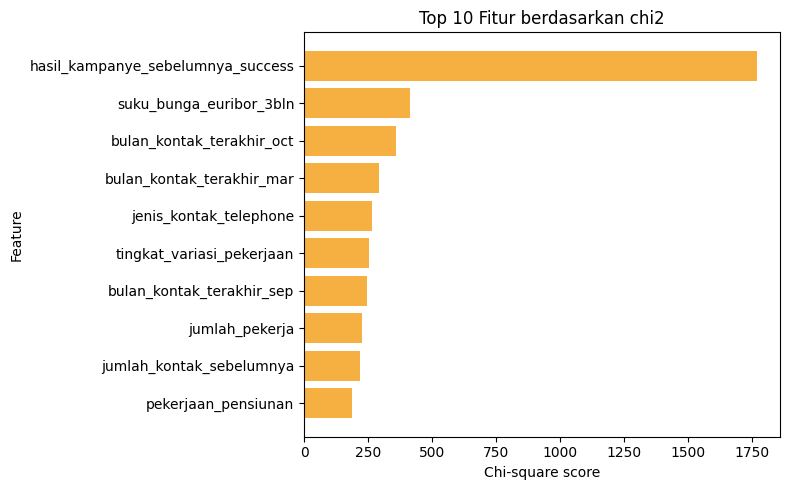

In [23]:
plt.figure(figsize=(8, 5))
plt.barh(chi2_scores.head(10)['feature'][::-1], chi2_scores.head(10)['score'][::-1], color='#f5b041')
plt.title('Top 10 Fitur berdasarkan chi2')
plt.xlabel('Chi-square score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [24]:
chi2_model = LogisticRegression(max_iter=2000, class_weight='balanced')
chi2_result = evaluate_model(chi2_model, X_train_chi2, X_test_chi2, y_train, y_test, 'SelectKBest + chi2', X_train_chi2.shape[1], chi2_features)
results.append(chi2_result)
feature_sets['SelectKBest + chi2'] = list(chi2_features)
chi2_result


{'method': 'SelectKBest + chi2',
 'n_features': 20,
 'accuracy': 0.7744328097731239,
 'precision': 0.2876142975893599,
 'recall': 0.6615678776290631,
 'f1': 0.40092699884125144,
 'selected_features': ['hari_sejak_kontak_sebelumnya',
  'jumlah_kontak_sebelumnya',
  'tingkat_variasi_pekerjaan',
  'indeks_harga_konsumen',
  'suku_bunga_euribor_3bln',
  'jumlah_pekerja',
  'pekerjaan_mahasiswa',
  'pekerjaan_pekerja kasar',
  'pekerjaan_pensiunan',
  'gagal_bayar_sebelumnya_unknown',
  'jenis_kontak_cellular',
  'jenis_kontak_telephone',
  'bulan_kontak_terakhir_apr',
  'bulan_kontak_terakhir_dec',
  'bulan_kontak_terakhir_mar',
  'bulan_kontak_terakhir_may',
  'bulan_kontak_terakhir_oct',
  'bulan_kontak_terakhir_sep',
  'hasil_kampanye_sebelumnya_nonexistent',
  'hasil_kampanye_sebelumnya_success']}

### 5.5 SelectPercentile

Alih-alih memilih jumlah fitur absolut, kita bisa memilih persentase fitur terbaik.

**Cocok untuk:**

- tipe fitur yang sama dengan score function yang dipakai
- sangat praktis untuk fitur hasil encoding yang jumlahnya cukup banyak


In [25]:
percentile_selector = SelectPercentile(score_func=f_classif, percentile=20)
X_train_pct = percentile_selector.fit_transform(X_train, y_train)
X_test_pct = percentile_selector.transform(X_test)
pct_features = X_train.columns[percentile_selector.get_support()]

pct_model = LogisticRegression(max_iter=2000, class_weight='balanced')
pct_result = evaluate_model(pct_model, X_train_pct, X_test_pct, y_train, y_test, 'SelectPercentile + f_classif', X_train_pct.shape[1], pct_features)
results.append(pct_result)
feature_sets['SelectPercentile + f_classif'] = list(pct_features)
pct_result


{'method': 'SelectPercentile + f_classif',
 'n_features': 14,
 'accuracy': 0.775523560209424,
 'precision': 0.2891666666666667,
 'recall': 0.6634799235181644,
 'f1': 0.4027858386535113,
 'selected_features': ['hari_sejak_kontak_sebelumnya',
  'jumlah_kontak_sebelumnya',
  'tingkat_variasi_pekerjaan',
  'indeks_harga_konsumen',
  'suku_bunga_euribor_3bln',
  'jumlah_pekerja',
  'pekerjaan_pensiunan',
  'jenis_kontak_cellular',
  'jenis_kontak_telephone',
  'bulan_kontak_terakhir_mar',
  'bulan_kontak_terakhir_oct',
  'bulan_kontak_terakhir_sep',
  'hasil_kampanye_sebelumnya_nonexistent',
  'hasil_kampanye_sebelumnya_success']}

### 5.6 GenericUnivariateSelect

Metode ini memberi antarmuka yang lebih fleksibel untuk memilih strategi univariat. Di sini kita pakai mode `k_best` sebagai ilustrasi.

**Cocok untuk:**

- fitur numerik atau hasil encoding
- tetap mengikuti score function yang dipilih di dalam selector


In [26]:
gus_selector = GenericUnivariateSelect(score_func=f_classif, mode='k_best', param=15)
X_train_gus = gus_selector.fit_transform(X_train, y_train)
X_test_gus = gus_selector.transform(X_test)
gus_features = X_train.columns[gus_selector.get_support()]

gus_model = LogisticRegression(max_iter=2000, class_weight='balanced')
gus_result = evaluate_model(gus_model, X_train_gus, X_test_gus, y_train, y_test, 'GenericUnivariateSelect', X_train_gus.shape[1], gus_features)
results.append(gus_result)
feature_sets['GenericUnivariateSelect'] = list(gus_features)
gus_result


{'method': 'GenericUnivariateSelect',
 'n_features': 15,
 'accuracy': 0.7615619546247818,
 'precision': 0.27734375,
 'recall': 0.6787762906309751,
 'f1': 0.39378813089295617,
 'selected_features': ['hari_sejak_kontak_sebelumnya',
  'jumlah_kontak_sebelumnya',
  'tingkat_variasi_pekerjaan',
  'indeks_harga_konsumen',
  'suku_bunga_euribor_3bln',
  'jumlah_pekerja',
  'pekerjaan_pensiunan',
  'jenis_kontak_cellular',
  'jenis_kontak_telephone',
  'bulan_kontak_terakhir_mar',
  'bulan_kontak_terakhir_may',
  'bulan_kontak_terakhir_oct',
  'bulan_kontak_terakhir_sep',
  'hasil_kampanye_sebelumnya_nonexistent',
  'hasil_kampanye_sebelumnya_success']}

### Perbandingan awal hasil filter methods


In [27]:
filter_results = pd.DataFrame(results)
filter_results[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1']].sort_values('f1', ascending=False)


,method,n_features,accuracy,precision,recall,f1
0,Baseline (all features),70,0.811082,0.333333,0.655832,0.442010
1,VarianceThreshold,68,0.809555,0.331081,0.655832,0.440026
3,SelectKBest + mutual_info,20,0.794284,0.309437,0.652008,0.419692
2,SelectKBest + f_classif,20,0.777051,0.290160,0.659656,0.403037
5,SelectPercentile + f_classif,14,0.775524,0.289167,0.663480,0.402786
4,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927
6,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788


## 6. Wrapper Methods

Pada bagian ini, subset fitur dievaluasi melalui model klasifikasi. Karena wrapper methods lebih mahal secara komputasi, kita mulai dari kandidat fitur yang sudah diperkecil menggunakan ranking `f_classif`.


In [28]:
wrapper_pool_size = 15
wrapper_pool = f_scores.head(wrapper_pool_size)['feature'].tolist()

X_train_wrapper = X_train[wrapper_pool].copy()
X_test_wrapper = X_test[wrapper_pool].copy()

print('Wrapper pool size:', len(wrapper_pool))
print(wrapper_pool)


Wrapper pool size: 15
['jumlah_pekerja', 'hari_sejak_kontak_sebelumnya', 'hasil_kampanye_sebelumnya_success', 'suku_bunga_euribor_3bln', 'tingkat_variasi_pekerjaan', 'jumlah_kontak_sebelumnya', 'hasil_kampanye_sebelumnya_nonexistent', 'jenis_kontak_telephone', 'jenis_kontak_cellular', 'indeks_harga_konsumen', 'bulan_kontak_terakhir_oct', 'bulan_kontak_terakhir_mar', 'bulan_kontak_terakhir_sep', 'pekerjaan_pensiunan', 'bulan_kontak_terakhir_may']


### 6.1 Sequential Forward Selection

**Cocok untuk:** fitur numerik dan fitur kategorikal yang sudah di-encoding ke numerik. Tidak dipakai langsung pada string mentah.


In [29]:
wrapper_model = LogisticRegression(max_iter=2000, class_weight='balanced')

sfs_forward = SequentialFeatureSelector(
    wrapper_model,
    n_features_to_select=8,
    direction='forward',
    scoring='f1',
    cv=5,
    n_jobs=-1
)

X_train_sfs_f = sfs_forward.fit_transform(X_train_wrapper, y_train)
X_test_sfs_f = sfs_forward.transform(X_test_wrapper)
sfs_forward_features = X_train_wrapper.columns[sfs_forward.get_support()]

sfs_forward_result = evaluate_model(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_sfs_f, X_test_sfs_f, y_train, y_test,
    'SFS Forward', X_train_sfs_f.shape[1], sfs_forward_features
)

results.append(sfs_forward_result)
feature_sets['SFS Forward'] = list(sfs_forward_features)
sfs_forward_result


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

{'method': 'SFS Forward',
 'n_features': 8,
 'accuracy': 0.8387870855148342,
 'precision': 0.37557603686635943,
 'recall': 0.6233269598470363,
 'f1': 0.46872753414809487,
 'selected_features': ['jumlah_pekerja',
  'hari_sejak_kontak_sebelumnya',
  'hasil_kampanye_sebelumnya_success',
  'jumlah_kontak_sebelumnya',
  'hasil_kampanye_sebelumnya_nonexistent',
  'bulan_kontak_terakhir_oct',
  'pekerjaan_pensiunan',
  'bulan_kontak_terakhir_may']}

### 6.2 Sequential Backward Selection

**Cocok untuk:** fitur numerik dan fitur kategorikal yang sudah di-encoding ke numerik. Tidak dipakai langsung pada string mentah.


In [30]:
sfs_backward = SequentialFeatureSelector(
    wrapper_model,
    n_features_to_select=8,
    direction='backward',
    scoring='f1',
    cv=5,
    n_jobs=-1
)

X_train_sfs_b = sfs_backward.fit_transform(X_train_wrapper, y_train)
X_test_sfs_b = sfs_backward.transform(X_test_wrapper)
sfs_backward_features = X_train_wrapper.columns[sfs_backward.get_support()]

sfs_backward_result = evaluate_model(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_sfs_b, X_test_sfs_b, y_train, y_test,
    'SFS Backward', X_train_sfs_b.shape[1], sfs_backward_features
)

results.append(sfs_backward_result)
feature_sets['SFS Backward'] = list(sfs_backward_features)
sfs_backward_result


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

{'method': 'SFS Backward',
 'n_features': 8,
 'accuracy': 0.8444589877835951,
 'precision': 0.38609112709832133,
 'recall': 0.615678776290631,
 'f1': 0.4745762711864407,
 'selected_features': ['jumlah_pekerja',
  'hari_sejak_kontak_sebelumnya',
  'jenis_kontak_telephone',
  'jenis_kontak_cellular',
  'indeks_harga_konsumen',
  'bulan_kontak_terakhir_mar',
  'bulan_kontak_terakhir_sep',
  'bulan_kontak_terakhir_may']}

### 6.3 Recursive Feature Elimination (RFE)

RFE menggunakan model untuk membuang fitur terlemah secara bertahap.

**Cocok untuk:** fitur numerik dan fitur hasil encoding, selama estimator yang dipakai memang menerima input numerik.


In [31]:
rfe_selector = RFE(
    estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
    n_features_to_select=8,
    step=1
)

X_train_rfe = rfe_selector.fit_transform(X_train_wrapper, y_train)
X_test_rfe = rfe_selector.transform(X_test_wrapper)
rfe_features = X_train_wrapper.columns[rfe_selector.get_support()]

rfe_ranking = pd.DataFrame({
    'feature': X_train_wrapper.columns,
    'ranking': rfe_selector.ranking_
}).sort_values(['ranking', 'feature'])

rfe_ranking


,feature,ranking
11,bulan_kontak_terakhir_mar,1
14,bulan_kontak_terakhir_may,1
10,bulan_kontak_terakhir_oct,1
6,hasil_kampanye_sebelumnya_nonexistent,1
2,hasil_kampanye_sebelumnya_success,1
9,indeks_harga_konsumen,1
7,jenis_kontak_telephone,1
4,tingkat_variasi_pekerjaan,1
13,pekerjaan_pensiunan,2
8,jenis_kontak_cellular,3


In [32]:
rfe_result = evaluate_model(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_rfe, X_test_rfe, y_train, y_test,
    'RFE', X_train_rfe.shape[1], rfe_features
)

results.append(rfe_result)
feature_sets['RFE'] = list(rfe_features)
rfe_result


{'method': 'RFE',
 'n_features': 8,
 'accuracy': 0.7626527050610821,
 'precision': 0.2798129384255651,
 'recall': 0.6864244741873805,
 'f1': 0.39756367663344405,
 'selected_features': ['hasil_kampanye_sebelumnya_success',
  'tingkat_variasi_pekerjaan',
  'hasil_kampanye_sebelumnya_nonexistent',
  'jenis_kontak_telephone',
  'indeks_harga_konsumen',
  'bulan_kontak_terakhir_oct',
  'bulan_kontak_terakhir_mar',
  'bulan_kontak_terakhir_may']}

### Perbandingan hasil wrapper methods


In [33]:
wrapper_results = pd.DataFrame(results)
wrapper_results[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1']].sort_values('f1', ascending=False)


,method,n_features,accuracy,precision,recall,f1
8,SFS Backward,8,0.844459,0.386091,0.615679,0.474576
7,SFS Forward,8,0.838787,0.375576,0.623327,0.468728
0,Baseline (all features),70,0.811082,0.333333,0.655832,0.442010
1,VarianceThreshold,68,0.809555,0.331081,0.655832,0.440026
3,SelectKBest + mutual_info,20,0.794284,0.309437,0.652008,0.419692
2,SelectKBest + f_classif,20,0.777051,0.290160,0.659656,0.403037
5,SelectPercentile + f_classif,14,0.775524,0.289167,0.663480,0.402786
4,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927
9,RFE,8,0.762653,0.279813,0.686424,0.397564
6,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788


## 7. Ringkasan Hasil

Di bawah ini kita gabungkan semua hasil agar bisa dibandingkan secara langsung.


In [34]:
results_df = pd.DataFrame(results)
summary_df = results_df[['method', 'n_features', 'accuracy', 'precision', 'recall', 'f1']].sort_values(['f1', 'accuracy'], ascending=False).reset_index(drop=True)
summary_df


,method,n_features,accuracy,precision,recall,f1
0,SFS Backward,8,0.844459,0.386091,0.615679,0.474576
1,SFS Forward,8,0.838787,0.375576,0.623327,0.468728
2,Baseline (all features),70,0.811082,0.333333,0.655832,0.442010
3,VarianceThreshold,68,0.809555,0.331081,0.655832,0.440026
4,SelectKBest + mutual_info,20,0.794284,0.309437,0.652008,0.419692
5,SelectKBest + f_classif,20,0.777051,0.290160,0.659656,0.403037
6,SelectPercentile + f_classif,14,0.775524,0.289167,0.663480,0.402786
7,SelectKBest + chi2,20,0.774433,0.287614,0.661568,0.400927
8,RFE,8,0.762653,0.279813,0.686424,0.397564
9,GenericUnivariateSelect,15,0.761562,0.277344,0.678776,0.393788


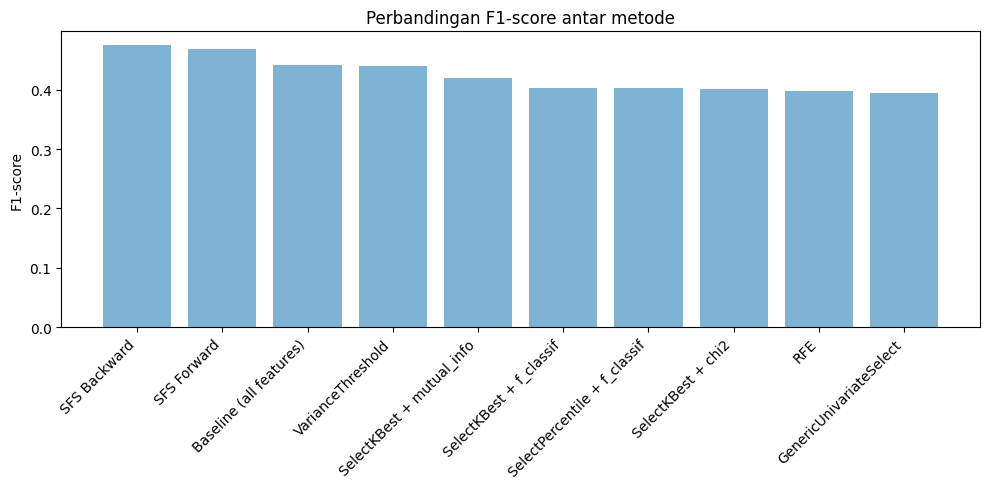

In [35]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df['method'], summary_df['f1'], color='#7fb3d5')
plt.title('Perbandingan F1-score antar metode')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [36]:
selected_feature_summary = pd.DataFrame({
    'method': list(feature_sets.keys()),
    'selected_features': [', '.join(features[:12]) + (' ...' if len(features) > 12 else '') for features in feature_sets.values()]
})
selected_feature_summary


,method,selected_features
0,Baseline (all features),"usia, jumlah_kontak_kampanye_ini, hari_sejak_k..."
1,VarianceThreshold,"usia, jumlah_kontak_kampanye_ini, hari_sejak_k..."
2,SelectKBest + f_classif,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
3,SelectKBest + mutual_info,"usia, hari_sejak_kontak_sebelumnya, jumlah_kon..."
4,SelectKBest + chi2,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
5,SelectPercentile + f_classif,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
6,GenericUnivariateSelect,"hari_sejak_kontak_sebelumnya, jumlah_kontak_se..."
7,SFS Forward,"jumlah_pekerja, hari_sejak_kontak_sebelumnya, ..."
8,SFS Backward,"jumlah_pekerja, hari_sejak_kontak_sebelumnya, ..."
9,RFE,"hasil_kampanye_sebelumnya_success, tingkat_var..."


### Observasi yang perlu diperhatikan

Beberapa hal yang biasanya muncul saat membandingkan hasil:

- metode filter yang berbeda bisa memilih fitur yang berbeda
- jumlah fitur lebih sedikit belum tentu memberi skor paling tinggi
- wrapper methods lebih mahal, tetapi kadang menghasilkan subset yang lebih sesuai model
- `chi2` sering kuat untuk dummy variables / fitur non-negative
- `mutual_info_classif` berguna saat hubungan fitur-target tidak cukup linear


## 8. Validasi pada Validation Set

Validation set yang disediakan tidak memiliki target. Jadi kita tidak bisa menghitung skor evaluasi final di sini. Tetapi kita tetap bisa menyiapkan fitur validation set agar pipeline konsisten.


In [37]:
X_valid_raw = df_valid.drop(columns=identifier_columns).copy()
X_valid_encoded = pd.get_dummies(X_valid_raw, columns=categorical_columns, drop_first=False, dtype=int)

# Samakan kolom dengan training set hasil encoding
X_valid_encoded = X_valid_encoded.reindex(columns=X_encoded.columns, fill_value=0)

print('Shape validation encoded:', X_valid_encoded.shape)
X_valid_encoded.head()


Shape validation encoded: (5729, 70)


,usia,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pekerjaan_asisten rumah tangga,pekerjaan_entrepreneur,pekerjaan_mahasiswa,pekerjaan_manajer,pekerjaan_pekerja kasar,pekerjaan_pemilik bisnis,pekerjaan_pengangguran,pekerjaan_pensiunan,pekerjaan_penyedia jasa,pekerjaan_sosial media specialis,pekerjaan_teknisi,pekerjaan_unknown,status_perkawinan_cerai,status_perkawinan_lajang,status_perkawinan_menikah,status_perkawinan_unknown,pendidikan_Diploma,pendidikan_Pendidikan Tinggi,pendidikan_SD,pendidikan_SMA,pendidikan_SMP,pendidikan_TIDAK SEKOLAH,pendidikan_Tidak Tamat SD,pendidikan_unknown,gagal_bayar_sebelumnya_no,gagal_bayar_sebelumnya_unknown,gagal_bayar_sebelumnya_yes,pinjaman_rumah_no,pinjaman_rumah_unknown,pinjaman_rumah_yes,pinjaman_pribadi_no,pinjaman_pribadi_unknown,pinjaman_pribadi_yes,jenis_kontak_cellular,jenis_kontak_telephone,bulan_kontak_terakhir_apr,bulan_kontak_terakhir_aug,bulan_kontak_terakhir_dec,bulan_kontak_terakhir_jul,bulan_kontak_terakhir_jun,bulan_kontak_terakhir_mar,bulan_kontak_terakhir_may,bulan_kontak_terakhir_nov,bulan_kontak_terakhir_oct,bulan_kontak_terakhir_sep,hari_kontak_terakhir_fri,hari_kontak_terakhir_mon,hari_kontak_terakhir_thu,hari_kontak_terakhir_tue,hari_kontak_terakhir_wed,hasil_kampanye_sebelumnya_failure,hasil_kampanye_sebelumnya_nonexistent,hasil_kampanye_sebelumnya_success,pulau_Bali,pulau_Jawa,pulau_Kalimantan,pulau_NTB,pulau_NTT,pulau_Papua,pulau_Sulawesi,pulau_Sumatera
0,35,1,999,0,1.4,93.918,-42.7,4.960,5228.1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
1,52,4,999,0,1.1,93.994,-36.4,4.860,5191.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0
2,37,3,999,0,1.1,93.994,-36.4,4.856,5191.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0
3,51,3,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1
4,45,1,999,1,-1.8,92.893,-46.2,1.327,5099.1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1


Contoh berikut menunjukkan cara memakai subset fitur hasil `SelectKBest + f_classif` untuk menghasilkan prediksi pada validation set.


In [38]:
best_demo_features = feature_sets['SelectKBest + f_classif']

final_model = LogisticRegression(max_iter=2000, class_weight='balanced')
final_model.fit(X_encoded[best_demo_features], y)
valid_predictions = final_model.predict(X_valid_encoded[best_demo_features])

pd.Series(valid_predictions).value_counts().sort_index()


0    4683
1    1046
Name: count, dtype: int64

## 9. Latihan Mandiri

1. Ubah `k_top` dari 20 menjadi 10 dan 30. Bagaimana perubahan performanya?
2. Bandingkan fitur terpilih antara `f_classif`, `mutual_info_classif`, dan `chi2`. Mana yang paling stabil?
3. Coba `SelectPercentile` dengan `percentile=10` dan `percentile=30`.
4. Ubah jumlah fitur pada SFS dan RFE dari 8 menjadi 5. Apakah performa turun banyak?
5. Apakah fitur-fitur yang dipilih metode filter juga sering dipilih oleh wrapper methods?
6. Menurut kalian, lebih baik mengejar **fitur sedikit tapi interpretable** atau **fitur lebih banyak tapi sedikit lebih akurat**? Jelaskan.
